# Project 1: Advanced EDA & Feature Engineering

**Goal:** Transform a raw, chaotic housing dataset into a mathematically clean dataset ready for machine learning, by:
1. Handling missing data via statistical imputation (Mean/Median/KNN)
2. Identifying and neutralizing outliers using IQR
3. Engineering at least 3 new predictive features
4. Encoding categoricals correctly (avoiding false numeric hierarchy)
5. Detecting and resolving multicollinearity

**Dataset:** `housing_data_raw.csv` — 1000 house listings with realistic messiness (missing values at different rates, a few extreme outliers, mixed numeric/categorical columns).

In [1]:
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

Load & Inspect the Data
Before touching anything, get a full picture: shape, dtypes, and where the gaps are.

In [2]:
df = pd.read_csv('housing_data_raw.csv')
print("Shape:", df.shape)
df.head()

Shape: (1000, 12)


,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_of_House_Years,Location,Furnishing_Status,Distance_to_City_Center_km,Floor_Number,Total_Floors_in_Building,Has_Parking,Price_Lakhs
0,HSE1507,1587.1,1,1.0,33.0,Rural,Semi-Furnished,3.95,9,18,Yes,44.76
1,HSE1818,1429.8,5,3.0,1.0,Downtown,Semi-Furnished,3.65,18,24,Yes,152.17
2,HSE1452,647.9,4,2.0,37.0,Suburb,Unfurnished,8.27,9,12,No,33.06
3,HSE1368,609.3,2,2.0,18.0,Downtown,Furnished,0.41,13,19,No,70.97
4,HSE1242,1595.9,4,3.0,29.0,Rural,Unfurnished,16.62,0,7,Yes,92.32


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   House_ID                    1000 non-null   str    
 1   Area_sqft                   970 non-null    float64
 2   Bedrooms                    1000 non-null   int64  
 3   Bathrooms                   890 non-null    float64
 4   Age_of_House_Years          910 non-null    float64
 5   Location                    940 non-null    str    
 6   Furnishing_Status           1000 non-null   str    
 7   Distance_to_City_Center_km  760 non-null    float64
 8   Floor_Number                1000 non-null   int64  
 9   Total_Floors_in_Building    1000 non-null   int64  
 10  Has_Parking                 1000 non-null   str    
 11  Price_Lakhs                 1000 non-null   float64
dtypes: float64(5), int64(3), str(4)
memory usage: 93.9 KB


In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
House_ID,1000,1000,HSE1507,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area_sqft,970.0,NaN,NaN,NaN,1542.721753,660.147247,400.0,1208.75,1500.15,1807.575,8504.4
Bedrooms,1000.0,NaN,NaN,NaN,3.064,1.402095,1.0,2.0,3.0,4.0,5.0
Bathrooms,890.0,NaN,NaN,NaN,2.435955,1.182384,1.0,1.0,2.0,3.0,5.0
Age_of_House_Years,910.0,NaN,NaN,NaN,21.936264,13.090121,0.0,11.0,22.0,34.0,44.0
Location,940,3,Suburb,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing_Status,1000,3,Semi-Furnished,397,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Distance_to_City_Center_km,760.0,NaN,NaN,NaN,7.975579,7.807501,0.3,2.26,5.445,11.335,40.0
Floor_Number,1000.0,NaN,NaN,NaN,9.737,5.842085,0.0,5.0,10.0,15.0,19.0
Total_Floors_in_Building,1000.0,NaN,NaN,NaN,17.221,7.257743,1.0,12.0,17.0,23.0,33.0


## Phase 1 : Securing Input Fidelity: The Missing Data Decision Matrix

Don't guess column by column. Apply a structural rule based on the **missingness proportion per feature**:

| Missingness | Action |
|---|---|
| < 5% | Drop rows (preserves data volume, avoids synthetic bias at this scale) |
| 5–20%, skewed numeric | Global median imputation |
| 5–20%, correlated with another column | Sub-group conditional imputation |
| > 20% | Multi-dimensional estimation (KNN imputation) |

Distance_to_City_Center_km    24.0
Bathrooms                     11.0
Age_of_House_Years             9.0
Location                       6.0
Area_sqft                      3.0
dtype: float64


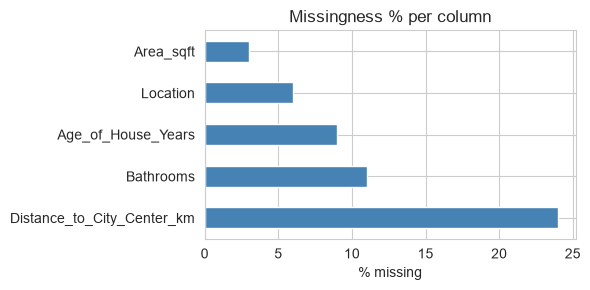

In [5]:
missing_pct = df.isna().mean().sort_values(ascending=False) * 100
missing_pct = missing_pct[missing_pct > 0]
print(missing_pct.round(2))

missing_pct.plot(kind='barh', figsize=(6,3), color='steelblue', title='Missingness % per column')
plt.xlabel('% missing')
plt.tight_layout()
plt.show()

**Applying the matrix to this dataset:**
- `Area_sqft` (~3%) → drop rows
- `Age_of_House_Years` (~9%, skewed numeric) → global median
- `Bathrooms` (~11%, correlated with Bedrooms) → sub-group conditional median, grouped by `Bedrooms`
- `Location` (categorical) → mode
- `Distance_to_City_Center_km` (~24%, >20%) → KNN imputation

In [6]:
# <5% missing -> drop rows
df = df.dropna(subset=['Area_sqft'])

# 5-20% skewed numeric -> global median
df['Age_of_House_Years'] = df['Age_of_House_Years'].fillna(df['Age_of_House_Years'].median())

# 5-20% correlated with Bedrooms -> sub-group conditional median
df['Bathrooms'] = df.groupby('Bedrooms')['Bathrooms'].transform(lambda s: s.fillna(s.median()))

# categorical -> mode
df['Location'] = df['Location'].fillna(df['Location'].mode()[0])

print("Missing after rule-based steps:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing after rule-based steps:
Distance_to_City_Center_km    235
dtype: int64


In [7]:
# >20% missing, numeric, multi-dimensional relationship -> KNN Imputation
knn_cols = ['Area_sqft', 'Bedrooms', 'Bathrooms', 'Age_of_House_Years', 'Distance_to_City_Center_km']
imputer = KNNImputer(n_neighbors=5)
df[knn_cols] = imputer.fit_transform(df[knn_cols])

print("Total remaining missing values:", df.isna().sum().sum())

Total remaining missing values: 0


## Phase 2 : Isolating & Neutralizing Outliers (IQR Method)

Outliers skew regression slopes and inflate variance. Using the IQR rule:

```
Lower Bound = Q1 - 1.5 * IQR
Upper Bound = Q3 + 1.5 * IQR
```

We use **winsorization** (`clip`) rather than deletion — this preserves row count and sequential integrity instead of destroying data volume.

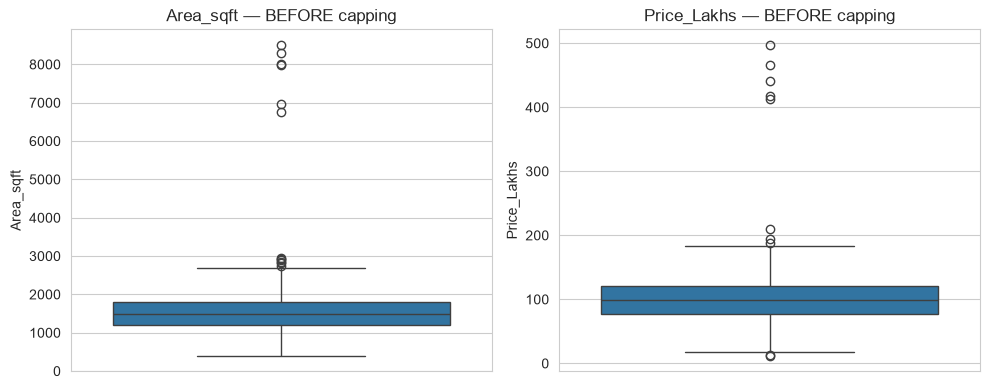

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['Area_sqft'], ax=axes[0]); axes[0].set_title('Area_sqft — BEFORE capping')
sns.boxplot(y=df['Price_Lakhs'], ax=axes[1]); axes[1].set_title('Price_Lakhs — BEFORE capping')
plt.tight_layout()
plt.show()

In [9]:
def iqr_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in ['Area_sqft', 'Price_Lakhs']:
    lo, hi = iqr_bounds(df[col])
    n_outliers = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col}: bounds=({lo:.1f}, {hi:.1f}) -> {n_outliers} outliers capped")
    df[col] = df[col].clip(lo, hi)

Area_sqft: bounds=(310.5, 2705.8) -> 12 outliers capped
Price_Lakhs: bounds=(13.8, 184.2) -> 10 outliers capped


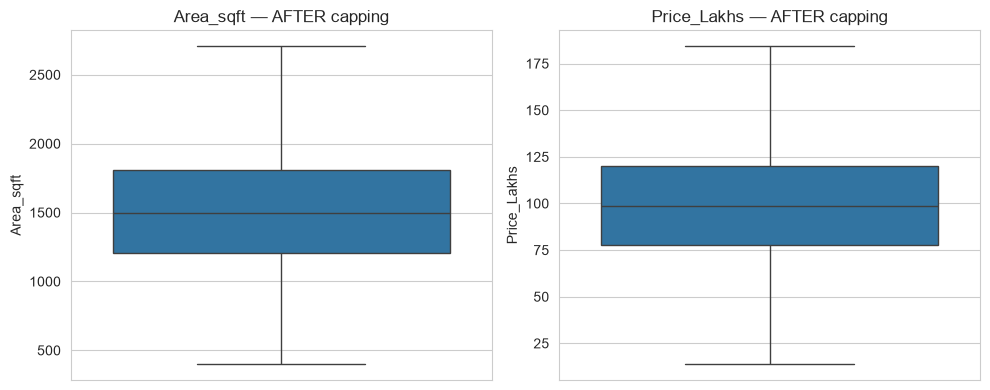

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(y=df['Area_sqft'], ax=axes[0]); axes[0].set_title('Area_sqft — AFTER capping')
sns.boxplot(y=df['Price_Lakhs'], ax=axes[1]); axes[1].set_title('Price_Lakhs — AFTER capping')
plt.tight_layout()
plt.show()

## Phase 3 : Feature Engineering (4 new predictive features)

Raw columns rarely carry the full signal on their own. We derive new features that should be more directly predictive of `Price_Lakhs`:

1. **`Price_per_sqft`** — normalizes price by size, useful for comparing listings
2. **`Total_Rooms`** — combined room count (Bedrooms + Bathrooms)
3. **`House_Age_Category`** — bins continuous age into New / Moderate / Old / Very Old
4. **`Floor_Ratio`** — relative floor position within the building (Floor_Number / Total_Floors)

In [11]:
df['Price_per_sqft'] = (df['Price_Lakhs'] * 100000) / df['Area_sqft']

df['Total_Rooms'] = df['Bedrooms'] + df['Bathrooms']

df['House_Age_Category'] = pd.cut(
    df['Age_of_House_Years'],
    bins=[-1, 5, 15, 30, 100],
    labels=['New', 'Moderate', 'Old', 'Very Old']
)

df['Floor_Ratio'] = df['Floor_Number'] / df['Total_Floors_in_Building']

df[['Price_per_sqft', 'Total_Rooms', 'House_Age_Category', 'Floor_Ratio']].head()

,Price_per_sqft,Total_Rooms,House_Age_Category,Floor_Ratio
0,2820.238170,2.0,Very Old,0.500000
1,10642.747237,8.0,New,0.750000
2,5102.639296,6.0,Very Old,0.750000
3,11647.792549,4.0,Old,0.684211
4,5784.823611,7.0,Old,0.000000


## Phase 4 : Categorical Translation into Coordinate Space

Estimators are numerical optimizers — assigning ascending integers to nominal categories (Label Encoding) introduces a **false mathematical hierarchy** (e.g. implying `Rural=2` is "twice" `Downtown=1`). **One-Hot Encoding** maps each category to its own orthogonal axis instead, avoiding that synthetic ordering.

In [12]:
categorical_cols = ['Location', 'Furnishing_Status', 'Has_Parking', 'House_Age_Category']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()

Shape after encoding: (970, 20)


,House_ID,Area_sqft,Bedrooms,Bathrooms,Age_of_House_Years,Distance_to_City_Center_km,Floor_Number,Total_Floors_in_Building,Price_Lakhs,Price_per_sqft,Total_Rooms,Floor_Ratio,Location_Rural,Location_Suburb,Furnishing_Status_Semi-Furnished,Furnishing_Status_Unfurnished,Has_Parking_Yes,House_Age_Category_Moderate,House_Age_Category_Old,House_Age_Category_Very Old
0,HSE1507,1587.1,1.0,1.0,33.0,3.95,9,18,44.76,2820.238170,2.0,0.500000,True,False,True,False,True,False,False,True
1,HSE1818,1429.8,5.0,3.0,1.0,3.65,18,24,152.17,10642.747237,8.0,0.750000,False,False,True,False,True,False,False,False
2,HSE1452,647.9,4.0,2.0,37.0,8.27,9,12,33.06,5102.639296,6.0,0.750000,False,True,False,True,False,False,False,True
3,HSE1368,609.3,2.0,2.0,18.0,0.41,13,19,70.97,11647.792549,4.0,0.684211,False,False,False,False,False,False,True,False
4,HSE1242,1595.9,4.0,3.0,29.0,16.62,0,7,92.32,5784.823611,7.0,0.000000,True,False,False,True,True,False,True,False


## Phase 5 : Detecting & Eradicating Multicollinearity

When predictor columns are highly correlated, the feature matrix becomes unstable for linear models (coefficients swing wildly with small data changes). Rule: **do not arbitrarily drop the first collinear column you find** — compare each candidate's correlation with the *target variable*, and drop the weaker link.

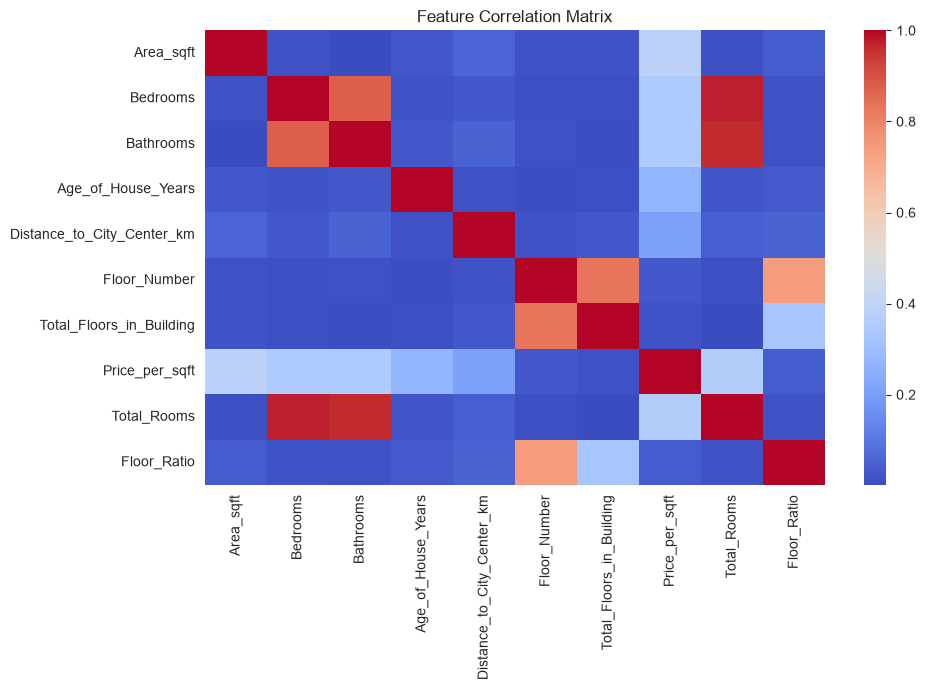

In [13]:
numeric_cols = df_encoded.select_dtypes(include=[np.number]).drop(columns=['Price_Lakhs'])
corr_matrix = numeric_cols.corr().abs()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [14]:
# Step 1-3 of the Collinearity Eradication Algorithm: build matrix, isolate upper triangle, find pairs > 0.8
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [
    (c1, c2, round(upper.loc[c1, c2], 3))
    for c1 in upper.columns for c2 in upper.columns
    if pd.notna(upper.loc[c1, c2]) and upper.loc[c1, c2] > 0.8
]
print("Highly collinear pairs (>0.8):")
for pair in high_corr_pairs:
    print(pair)

Highly collinear pairs (>0.8):
('Bedrooms', 'Bathrooms', np.float64(0.878))
('Bedrooms', 'Total_Rooms', np.float64(0.975))
('Bathrooms', 'Total_Rooms', np.float64(0.963))
('Floor_Number', 'Total_Floors_in_Building', np.float64(0.833))


In [15]:
# Step 4: Target comparison -- for each collinear pair, keep whichever correlates more strongly with Price_Lakhs
target_corr = df_encoded.corr(numeric_only=True)['Price_Lakhs']
candidates = ['Bedrooms', 'Bathrooms', 'Total_Rooms', 'Floor_Number', 'Total_Floors_in_Building']
print(target_corr[candidates].sort_values(ascending=False))

# Total_Rooms captures Bedrooms + Bathrooms with the strongest target correlation -> keep it, drop the redundant originals.
# Floor_Number and Total_Floors_in_Building are both weak vs target but collinear with each other -> drop the weaker one.
df_encoded = df_encoded.drop(columns=['Bedrooms', 'Bathrooms', 'Total_Floors_in_Building'])
print("\nFinal column count:", df_encoded.shape[1])

Total_Rooms                 0.345591
Bathrooms                   0.336347
Bedrooms                    0.333846
Floor_Number               -0.018377
Total_Floors_in_Building   -0.029142
Name: Price_Lakhs, dtype: float64

Final column count: 17


## Phase 6 : Final Export

The dataset is now: missing-value free, outlier-capped, enriched with engineered features, properly encoded, and free of severe multicollinearity. It's ready to feed into a regression/ML estimator.

In [16]:
df_encoded.to_csv('housing_data_cleaned.csv', index=False)
print("Saved housing_data_cleaned.csv")
print("Final shape:", df_encoded.shape)
df_encoded.describe().T

Saved housing_data_cleaned.csv
Final shape: (970, 17)


,count,mean,std,min,25%,50%,75%,max
Area_sqft,970.0,1510.540155,446.299088,400.000000,1208.750000,1500.150000,1807.575000,2705.8125
Age_of_House_Years,970.0,21.914433,12.523987,0.000000,12.000000,22.000000,33.000000,44.0000
Distance_to_City_Center_km,970.0,7.951981,6.931205,0.300000,3.097500,6.244000,10.718500,40.0000
Floor_Number,970.0,9.749485,5.830963,0.000000,5.000000,10.000000,15.000000,19.0000
Price_Lakhs,970.0,98.894732,32.290019,13.845000,77.737500,98.375000,120.332500,184.2250
Price_per_sqft,970.0,6805.789863,2287.348736,1264.730063,5337.524035,6518.755035,7852.654591,20795.0000
Total_Rooms,970.0,5.506186,2.480983,2.000000,4.000000,5.000000,8.000000,10.0000
Floor_Ratio,970.0,0.531958,0.248136,0.000000,0.389493,0.573593,0.707721,0.9500


## Summary

| Step | What we did | Why |
|---|---|---|
| Missing data | Drop / median / group-median / mode / KNN, chosen by missingness % | Matches the data's actual uncertainty level instead of one-size-fits-all |
| Outliers | IQR bounds + `clip()` (winsorization) | Removes distortion without losing rows |
| Feature engineering | 4 new columns (`Price_per_sqft`, `Total_Rooms`, `House_Age_Category`, `Floor_Ratio`) | Surfaces relationships the raw columns hide |
| Encoding | One-Hot instead of Label Encoding | Avoids inventing a false numeric ordering between categories |
| Multicollinearity | Correlation matrix + target-comparison drop rule | Keeps the strongest signal, removes redundant/unstable predictors |
